                 Model  Accuracy  Precision    Recall        F1
0                  KNN  0.733333   0.728812  0.733333  0.726851
1  Logistic Regression  0.711111   0.691644  0.711111  0.687485
2                  SVC  0.718519   0.702361  0.718519  0.683848
3        Random Forest  0.696296   0.683811  0.696296  0.682034
4    Gradient Boosting  0.666667   0.664572  0.666667  0.663072


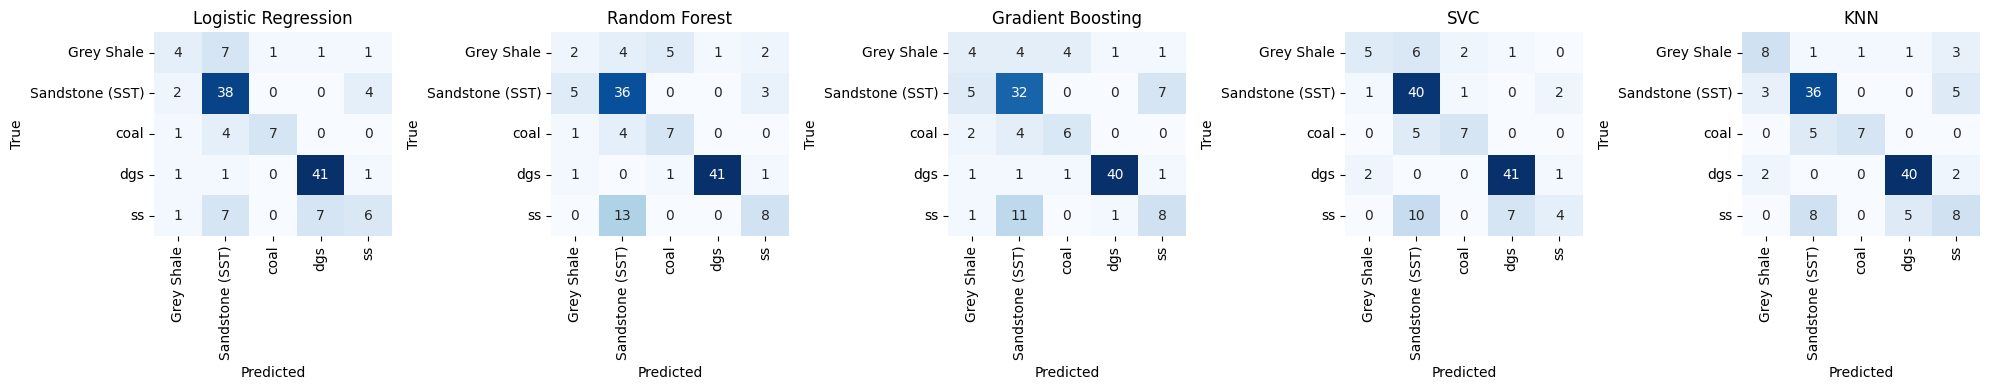

KNN
0.7268512569064184


In [ ]:
# Steps: load existing df in memory, prepare features/labels, split, scale, train models, evaluate, plot confusions, and summarize
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
import matplotlib.pyplot as plt

# Assume df_well already exists from earlier steps; if not, read from disk
try:
    df = df_well.copy()
except NameError:
    df = pd.read_csv('Well_1_dataset.csv', encoding='ascii')

# Select features and target
features = ['CALIPER[MM]', 'DEN[GM/CC]', 'RES(64N)', 'RES[OHM]', 'SP[MV]', 'GAM[API]']
X = df[features].copy()
y = df['Classified'].astype(str)

# Train-test split (stratify to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Define models within pipelines (scale where needed)
models = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, n_jobs=None))]),
    'Random Forest': Pipeline([('clf', RandomForestClassifier(n_estimators=300, random_state=42))]),
    'Gradient Boosting': Pipeline([('clf', GradientBoostingClassifier(random_state=42))]),
    'SVC': Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='rbf', probability=True, random_state=42))]),
    'KNN': Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier(n_neighbors=7))])
}

# Train and evaluate
results = []
conf_mats = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})
    conf_mats[name] = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))

# Create comparison table
results_df = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)
print(results_df.head())

# Plot confusion matrices
labels_sorted = sorted(y.unique())
fig, axes = plt.subplots(1, len(models), figsize=(4*len(models), 4))
if len(models) == 1:
    axes = [axes]
for ax, (name, cm) in zip(axes, conf_mats.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=labels_sorted, yticklabels=labels_sorted)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('confusion_matrices.png')
plt.show()

# Save comparison table
results_df.to_csv('model_performance_summary.csv', index=False)

# Identify best model
best_row = results_df.iloc[0]
print(best_row['Model'])
print(best_row['F1'])

Feature Importance

       Feature  Importance
4       SP[MV]    0.225289
0  CALIPER[MM]    0.179091
3     RES[OHM]    0.155618
2     RES(64N)    0.155050
5     GAM[API]    0.154636
1   DEN[GM/CC]    0.130317


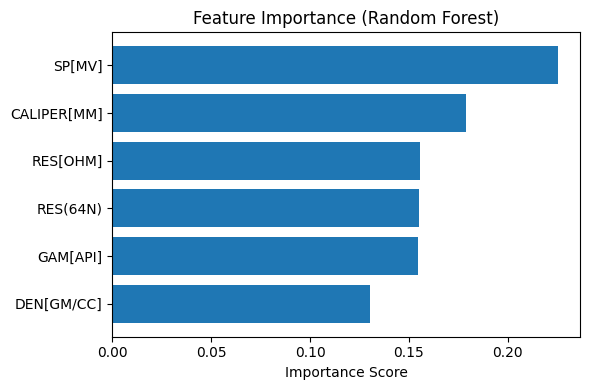

In [ ]:
rf_pipe = models['Random Forest']
rf_pipe.fit(X_train, y_train)

rf_model = rf_pipe.named_steps['clf']

importances = rf_model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(feat_imp)

plt.figure(figsize=(6,4))
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.xlabel('Importance Score')
plt.title('Feature Importance (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


feature importance - SHAP

In [ ]:
pip install shap


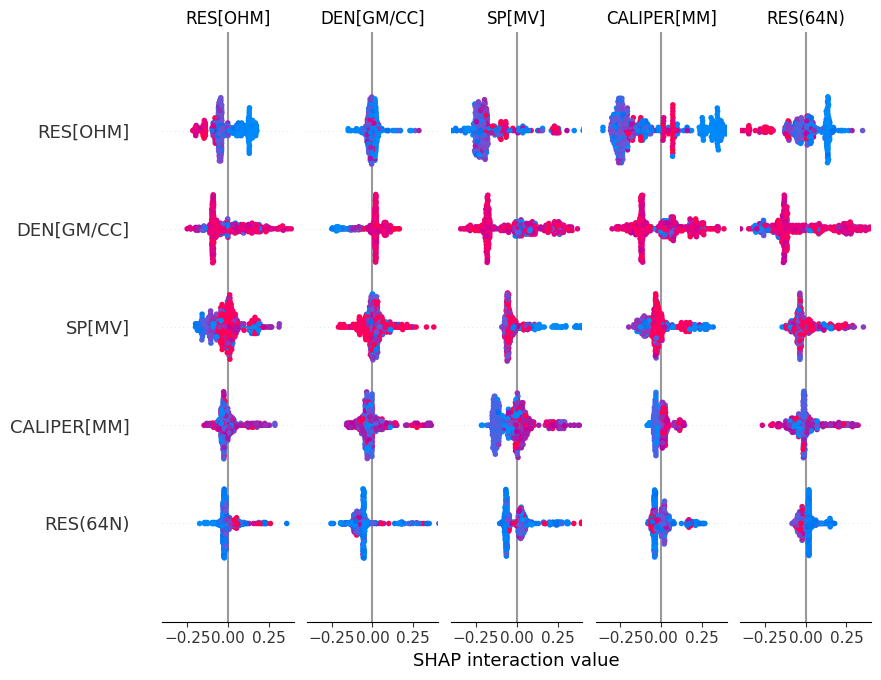

In [ ]:
rf_pipe = models['Random Forest']
rf_pipe.fit(X_train, y_train)

rf_model = rf_pipe.named_steps['clf']

import shap

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train, feature_names=features)


In [ ]:
df.head()

,DEPT[M],WELL,CALIPER[MM],DEN[GM/CC],RES(64N),RES[OHM],SP[MV],GAM[API],LITHOLOGY DESCRIPTION,Formation,Classified
0,24.00,1,12.6696,2.59367,4.50623,21.0600,64.5311,77.5320,"Fine graineded SST, brown",Raniganj,Sandstone (SST)
1,24.89,1,12.6886,2.30613,3.39083,22.2852,56.2742,79.1260,"Fine graineded SST, brown",Raniganj,Sandstone (SST)
2,25.64,1,12.6645,2.32154,3.11173,22.5185,48.2233,74.8741,Grey Shale,Raniganj,Grey Shale
3,26.70,1,12.6506,2.15749,3.57612,24.0353,48.1409,114.1800,"Grey shale, clayey",Raniganj,Grey Shale
4,28.65,1,12.6297,2.15362,3.06528,24.3850,42.9521,142.3170,Grey shale,Raniganj,Grey Shale


Unique values in 'Classified' column

In [ ]:
import pandas as pd

# Assume df_well already exists from earlier steps; if not, read from disk
try:
    df = df_well.copy()
except NameError:
    df = pd.read_csv('Well_1_dataset.csv', encoding='ascii')

print("Unique values in 'Classified' column:")
print(df['Classified'].unique())

Unique values in 'Classified' column:
['Sandstone (SST)' 'Grey Shale' 'dgs' 'coal' 'ss']


distribution fo classes in "Classified" columns

In [ ]:
print("\nDistribution of classes in 'Classified' column:")
print(df['Classified'].value_counts())


Distribution of classes in 'Classified' column:
Classified
dgs                175
Sandstone (SST)    174
ss                  83
Grey Shale          58
coal                47
Name: count, dtype: int64


Classification Report

In [ ]:
from sklearn.metrics import classification_report

# Generate classification reports for each model
for name, pipe in models.items():
    y_pred = pipe.predict(X_test)
    print(f"--- Classification Report for {name} ---")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("\n")

--- Classification Report for Logistic Regression ---
                 precision    recall  f1-score   support

     Grey Shale       0.44      0.29      0.35        14
Sandstone (SST)       0.67      0.86      0.75        44
           coal       0.88      0.58      0.70        12
            dgs       0.84      0.93      0.88        44
             ss       0.50      0.29      0.36        21

       accuracy                           0.71       135
      macro avg       0.66      0.59      0.61       135
   weighted avg       0.69      0.71      0.69       135



--- Classification Report for Random Forest ---
                 precision    recall  f1-score   support

     Grey Shale       0.22      0.14      0.17        14
Sandstone (SST)       0.63      0.82      0.71        44
           coal       0.54      0.58      0.56        12
            dgs       0.98      0.93      0.95        44
             ss       0.57      0.38      0.46        21

       accuracy                     

**Actual Vs Predictions**

In [ ]:
# Find the best model (based on the previous evaluation results_df)
best_model_name = results_df.iloc[0]['Model']
best_model_pipe = models[best_model_name]

# Predict on the entire dataset using the best model
df['predicted'] = best_model_pipe.predict(X)

# Save the new dataset with the 'predicted' column
output_filename_pred = 'Well_1_pred_actual.csv'
df.to_csv(output_filename_pred, index=False)

print(f"New dataset with 'predicted' column saved as '{output_filename_pred}'")
print("Shape of the new dataset:", df.shape)
print("\nFirst 5 rows of the new dataset with 'predicted' column:")
print(df[['DEPT[M]', 'Classified', 'predicted']].head())

New dataset with 'predicted' column saved as 'Well_1_pred_actual.csv'
Shape of the new dataset: (537, 12)

First 5 rows of the new dataset with 'predicted' column:
   DEPT[M]       Classified        predicted
0    24.00  Sandstone (SST)  Sandstone (SST)
1    24.89  Sandstone (SST)       Grey Shale
2    25.64       Grey Shale       Grey Shale
3    26.70       Grey Shale       Grey Shale
4    28.65       Grey Shale       Grey Shale


In [ ]:
df1 = pd.read_csv('Well_1_pred_actual.csv')
df.head()

,DEPT[M],WELL,CALIPER[MM],DEN[GM/CC],RES(64N),RES[OHM],SP[MV],GAM[API],LITHOLOGY DESCRIPTION,Formation,Classified,predicted
0,24.00,1,12.6696,2.59367,4.50623,21.0600,64.5311,77.5320,"Fine graineded SST, brown",Raniganj,Sandstone (SST),Sandstone (SST)
1,24.89,1,12.6886,2.30613,3.39083,22.2852,56.2742,79.1260,"Fine graineded SST, brown",Raniganj,Sandstone (SST),Grey Shale
2,25.64,1,12.6645,2.32154,3.11173,22.5185,48.2233,74.8741,Grey Shale,Raniganj,Grey Shale,Grey Shale
3,26.70,1,12.6506,2.15749,3.57612,24.0353,48.1409,114.1800,"Grey shale, clayey",Raniganj,Grey Shale,Grey Shale
4,28.65,1,12.6297,2.15362,3.06528,24.3850,42.9521,142.3170,Grey shale,Raniganj,Grey Shale,Grey Shale


**Visualization**

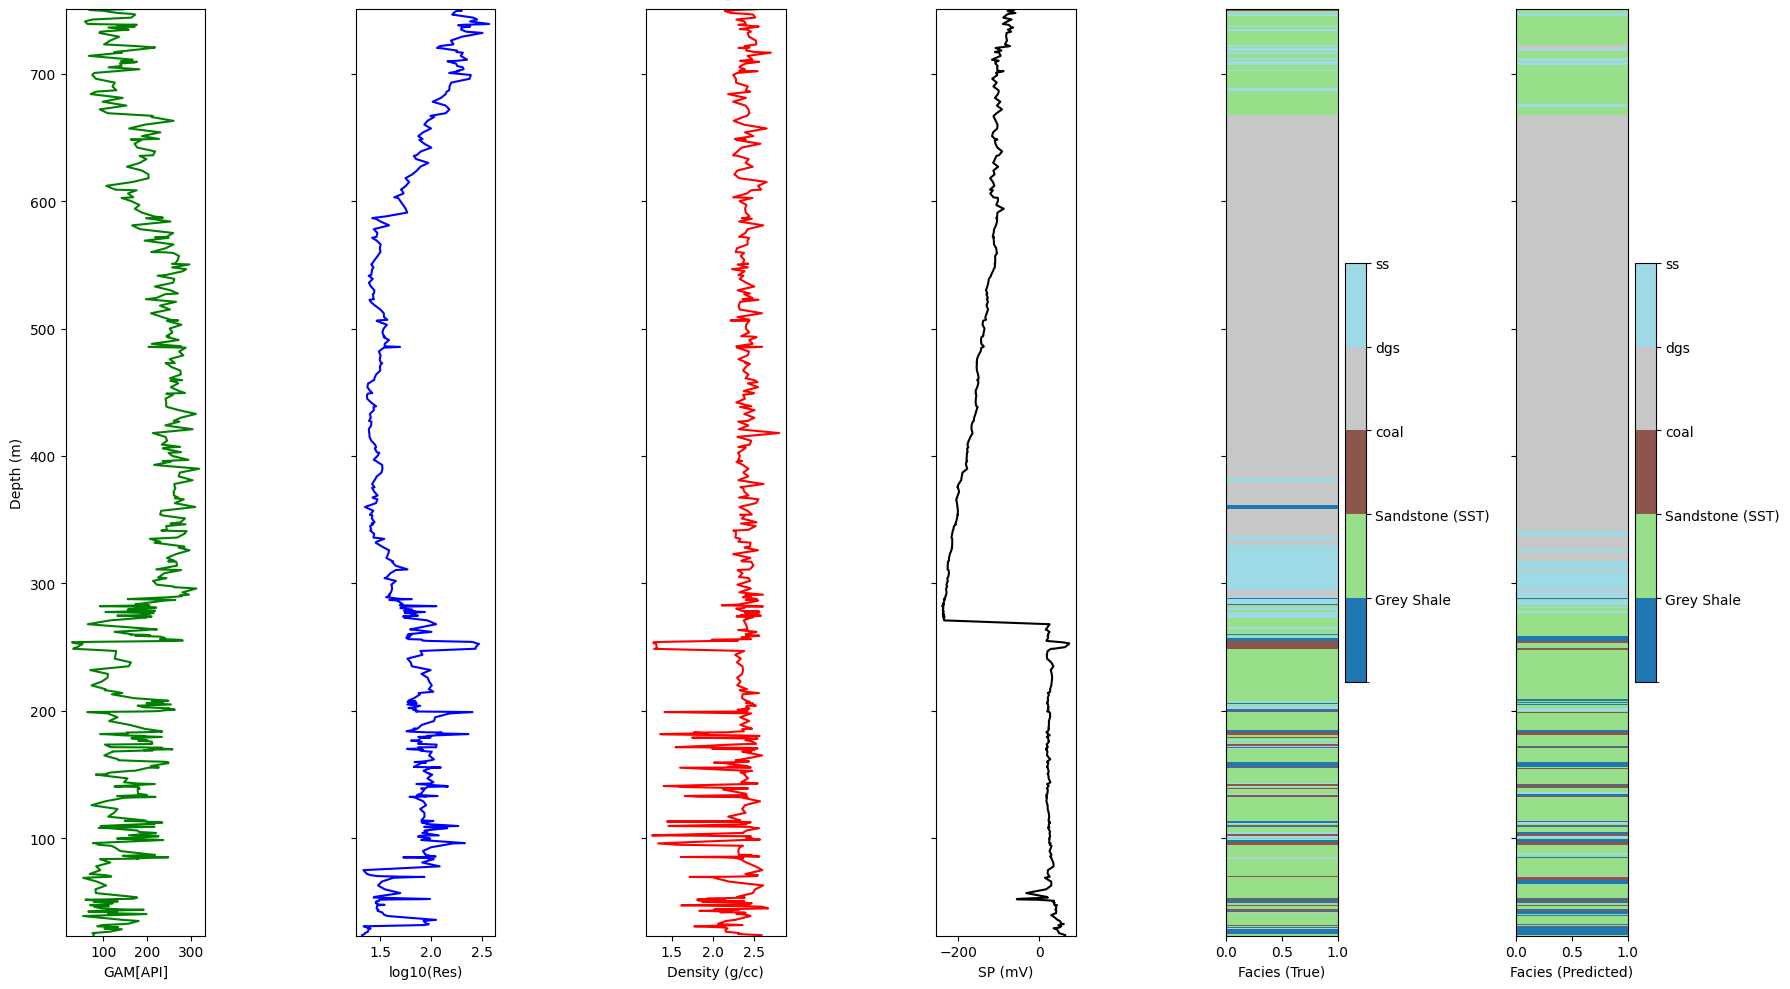

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

df = pd.read_csv("Well_1_pred_actual.csv")
df['DEPT[M]'] = pd.to_numeric(df['DEPT[M]'], errors='coerce')
df = df.sort_values('DEPT[M]').reset_index(drop=True)

# explicit facies order (important!)
unique_facies = sorted(df['Classified'].unique())  # or define your known order
facies_mapping = {f:i for i,f in enumerate(unique_facies)}

df['Classified_numeric'] = df['Classified'].map(facies_mapping).astype(int)
df['predicted_numeric'] = df['predicted'].map(facies_mapping).astype(int)

# build discrete colormap
cmap = plt.get_cmap('tab20', len(unique_facies))
listed_cmap = ListedColormap([cmap(i) for i in range(len(unique_facies))])
norm = BoundaryNorm(np.arange(-0.5, len(unique_facies)+0.5, 1), listed_cmap.N)

fig, ax = plt.subplots(1,6, figsize=(18,10), sharey=True)
ax[0].plot(df["GAM[API]"], df["DEPT[M]"], 'g')
ax[0].invert_yaxis()
ax[0].set_ylabel("Depth (m)")
ax[0].set_xlabel("GAM[API]")

ax[1].plot(np.log10(df["RES[OHM]"]), df["DEPT[M]"], 'b')
ax[1].set_xlabel("log10(Res)")

ax[2].plot(df["DEN[GM/CC]"], df["DEPT[M]"], 'r')
ax[2].set_xlabel("Density (g/cc)")

ax[3].plot(df["SP[MV]"], df["DEPT[M]"], 'k')
ax[3].set_xlabel("SP (mV)")

# For facies columns use pcolormesh to map each row to exact depth interval
depth = df['DEPT[M]'].values
# create depth edges for pcolormesh (midpoints)
edges = np.concatenate([[depth[0] - 0.5*(depth[1]-depth[0])], (depth[:-1]+depth[1:])/2, [depth[-1] + 0.5*(depth[-1]-depth[-2])]])
# 2D arrays with shape (len(depth), 1)
x = np.array([0,1])
# classified
arr_class = df['Classified_numeric'].values.reshape(-1,1)
pcm = ax[4].pcolormesh(x, edges, arr_class, cmap=listed_cmap, norm=norm, shading='flat')
ax[4].set_xlabel("Facies (True)")
cbar4 = plt.colorbar(pcm, ax=ax[4], ticks=np.arange(len(unique_facies))+0.5)
cbar4.set_ticklabels(unique_facies)

# predicted
arr_pred = df['predicted_numeric'].values.reshape(-1,1)
pcm2 = ax[5].pcolormesh(x, edges, arr_pred, cmap=listed_cmap, norm=norm, shading='flat')
ax[5].set_xlabel("Facies (Predicted)")
cbar5 = plt.colorbar(pcm2, ax=ax[5], ticks=np.arange(len(unique_facies))+0.5)
cbar5.set_ticklabels(unique_facies)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


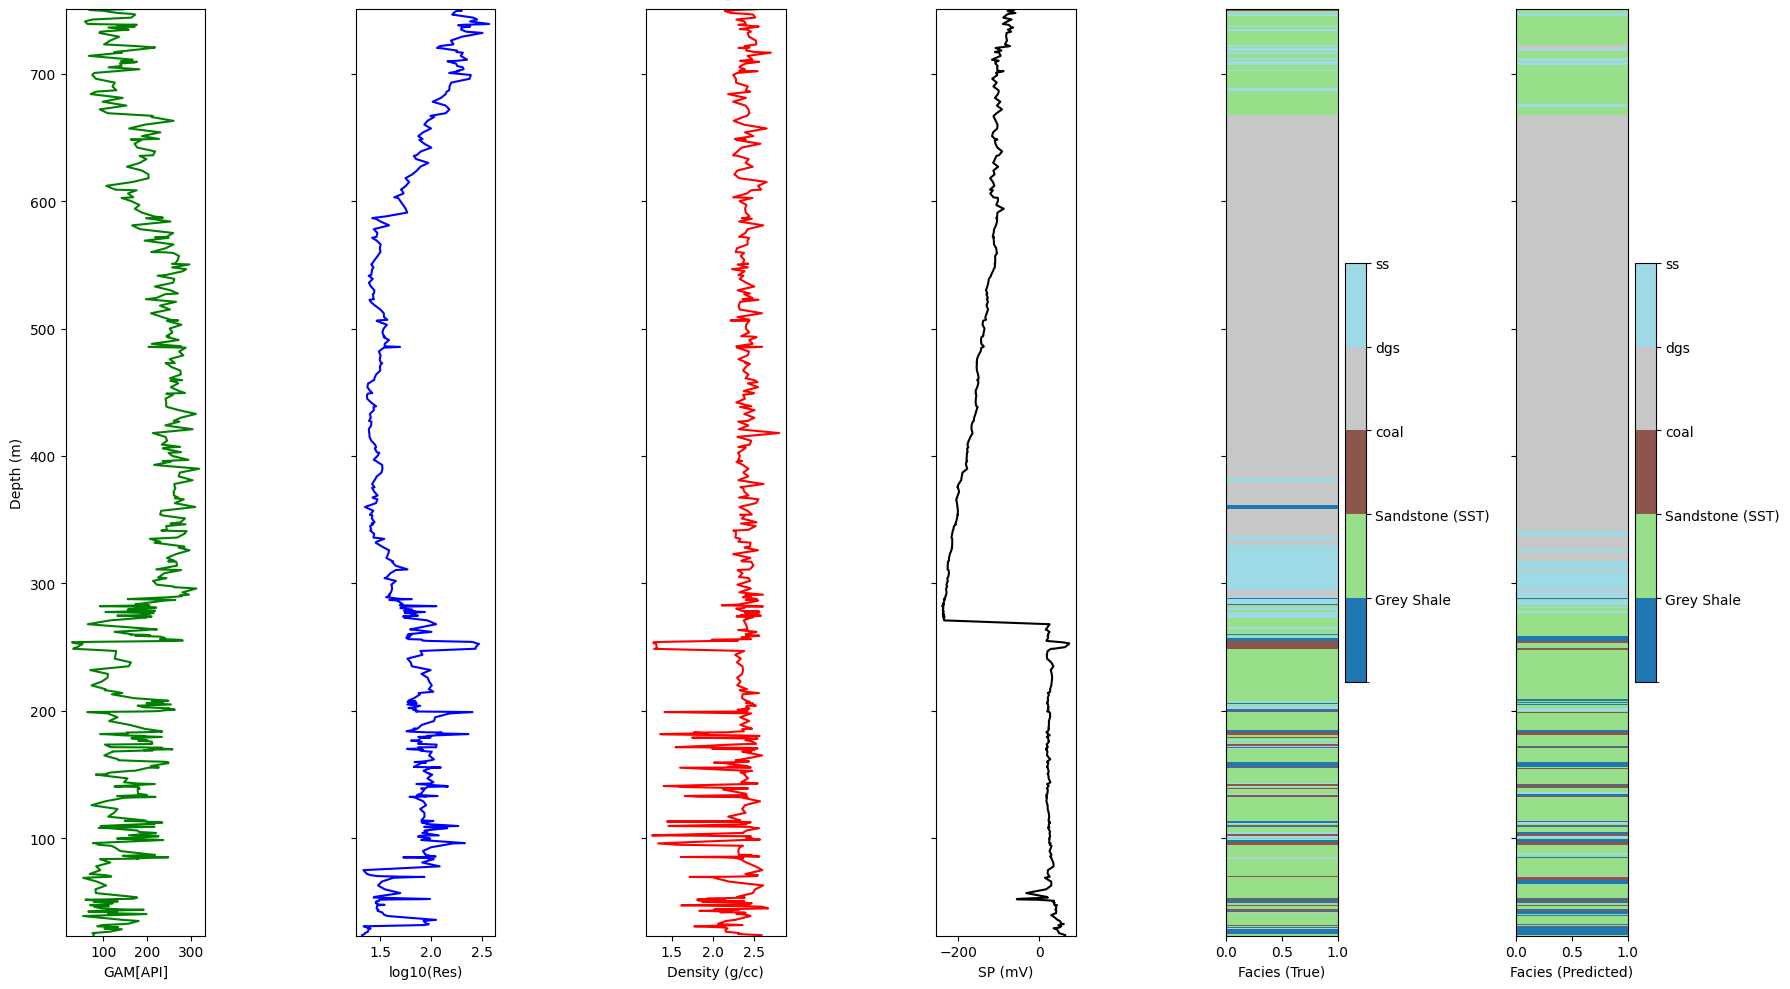

TypeError: Dimensions of C (537, 1) are incompatible with X (2) and/or Y (538); see help(pcolormesh)

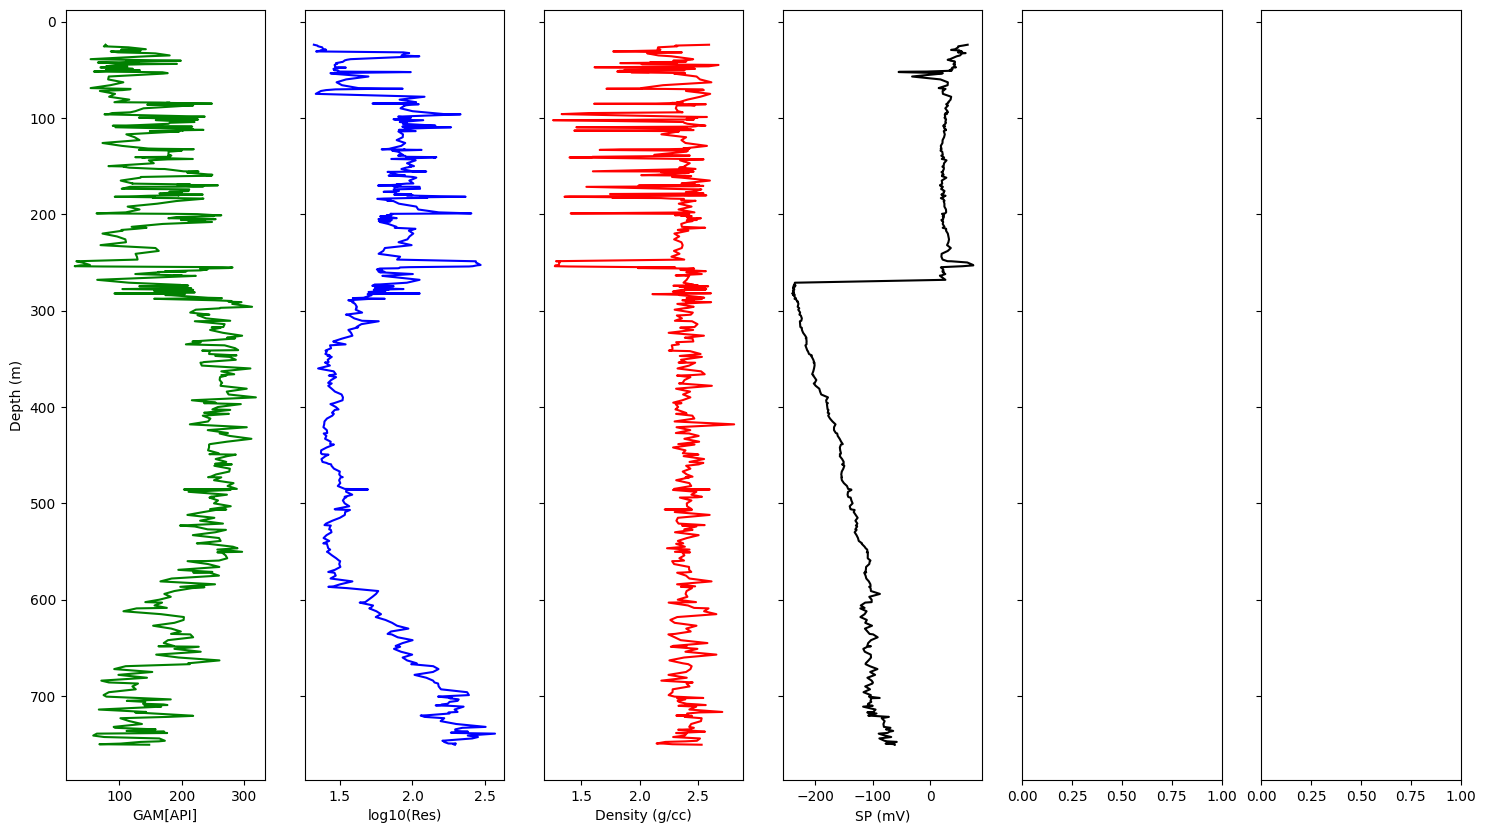

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

df = pd.read_csv("Well_1_pred_actual.csv")
df['DEPT[M]'] = pd.to_numeric(df['DEPT[M]'], errors='coerce')
df = df.sort_values('DEPT[M]').reset_index(drop=True)

# explicit facies order (important!)
unique_facies = sorted(df['Classified'].unique())  # or define your known order
facies_mapping = {f:i for i,f in enumerate(unique_facies)}

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

df = pd.read_csv("Well_1_pred_actual.csv")
df['DEPT[M]'] = pd.to_numeric(df['DEPT[M]'], errors='coerce')
df = df.sort_values('DEPT[M]').reset_index(drop=True)

# explicit facies order (important!)
unique_facies = sorted(df['Classified'].unique())  # or define your known order
facies_mapping = {f:i for i,f in enumerate(unique_facies)}

df['Classified_numeric'] = df['Classified'].map(facies_mapping).astype(int)
df['predicted_numeric'] = df['predicted'].map(facies_mapping).astype(int)

# build discrete colormap
cmap = plt.get_cmap('tab20', len(unique_facies))
listed_cmap = ListedColormap([cmap(i) for i in range(len(unique_facies))])
norm = BoundaryNorm(np.arange(-0.5, len(unique_facies)+0.5, 1), listed_cmap.N)

fig, ax = plt.subplots(1,6, figsize=(18,10), sharey=True)
ax[0].plot(df["GAM[API]"], df["DEPT[M]"], 'g')
ax[0].invert_yaxis()
ax[0].set_ylabel("Depth (m)")
ax[0].set_xlabel("GAM[API]")

ax[1].plot(np.log10(df["RES[OHM]"]), df["DEPT[M]"], 'b')
ax[1].set_xlabel("log10(Res)")

ax[2].plot(df["DEN[GM/CC]"], df["DEPT[M]"], 'r')
ax[2].set_xlabel("Density (g/cc)")

ax[3].plot(df["SP[MV]"], df["DEPT[M]"], 'k')
ax[3].set_xlabel("SP (mV)")

# For facies columns use pcolormesh to map each row to exact depth interval
depth = df['DEPT[M]'].values
# create depth edges for pcolormesh (midpoints)
edges = np.concatenate([[depth[0] - 0.5*(depth[1]-depth[0])], (depth[:-1]+depth[1:])/2, [depth[-1] + 0.5*(depth[-1]-depth[-2])]])
# 2D arrays with shape (len(depth), 1)
x = np.array([0,1])
# classified
arr_class = df['Classified_numeric'].values.reshape(-1,1)
pcm = ax[4].pcolormesh(x, edges, arr_class, cmap=listed_cmap, norm=norm, shading='flat')
ax[4].set_xlabel("Facies (True)")
cbar4 = plt.colorbar(pcm, ax=ax[4], ticks=np.arange(len(unique_facies))+0.5)
cbar4.set_ticklabels(unique_facies)

# predicted
arr_pred = df['predicted_numeric'].values.reshape(-1,1)
pcm2 = ax[5].pcolormesh(x, edges, arr_pred, cmap=listed_cmap, norm=norm, shading='flat')
ax[5].set_xlabel("Facies (Predicted)")
cbar5 = plt.colorbar(pcm2, ax=ax[5], ticks=np.arange(len(unique_facies))+0.5)
cbar5.set_ticklabels(unique_facies)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# build discrete colormap
cmap = plt.get_cmap('tab20', len(unique_facies))
listed_cmap = ListedColormap([cmap(i) for i in range(len(unique_facies))])
norm = BoundaryNorm(np.arange(-0.5, len(unique_facies)+0.5, 1), listed_cmap.N)

fig, ax = plt.subplots(1,6, figsize=(18,10), sharey=True)
ax[0].plot(df["GAM[API]"], df["DEPT[M]"], 'g')
ax[0].invert_yaxis()
ax[0].set_ylabel("Depth (m)")
ax[0].set_xlabel("GAM[API]")

ax[1].plot(np.log10(df["RES[OHM]"]), df["DEPT[M]"], 'b')
ax[1].set_xlabel("log10(Res)")

ax[2].plot(df["DEN[GM/CC]"], df["DEPT[M]"], 'r')
ax[2].set_xlabel("Density (g/cc)")

ax[3].plot(df["SP[MV]"], df["DEPT[M]"], 'k')
ax[3].set_xlabel("SP (mV)")

# For facies columns use pcolormesh to map each row to exact depth interval
depth = df['DEPT[M]'].values
# create depth edges for pcolormesh (midpoints)
edges = np.concatenate([[depth[0] - 0.5*(depth[1]-depth[0])], (depth[:-1]+depth[1:])/2, [depth[-1] + 0.5*(depth[-1]-depth[-2])]])
# 2D arrays with shape (len(depth), 1)
x = np.array([0,1])
# classified
arr_class = df['Classified_numeric'].values.reshape(-1,1)
pcm = ax[4].pcolormesh(
    x, edges, arr_class,
    cmap=listed_cmap,
    norm=norm,
    shading='nearest'
)
ax[4].set_xlabel("Facies (True)")
cbar4 = plt.colorbar(pcm, ax=ax[4], ticks=np.arange(len(unique_facies))+0.5)
cbar4.set_ticklabels(unique_facies)

# predicted
arr_pred = df['predicted_numeric'].values.reshape(-1,1)
pcm2 = ax[5].pcolormesh(x, edges, arr_pred, cmap=listed_cmap, norm=norm, shading='flat')
ax[5].set_xlabel("Facies (Predicted)")
cbar5 = plt.colorbar(pcm2, ax=ax[5], ticks=np.arange(len(unique_facies))+0.5)
cbar5.set_ticklabels(unique_facies)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


TypeError: Dimensions of C (537, 2) are incompatible with X (2) and/or Y (538); see help(pcolormesh)

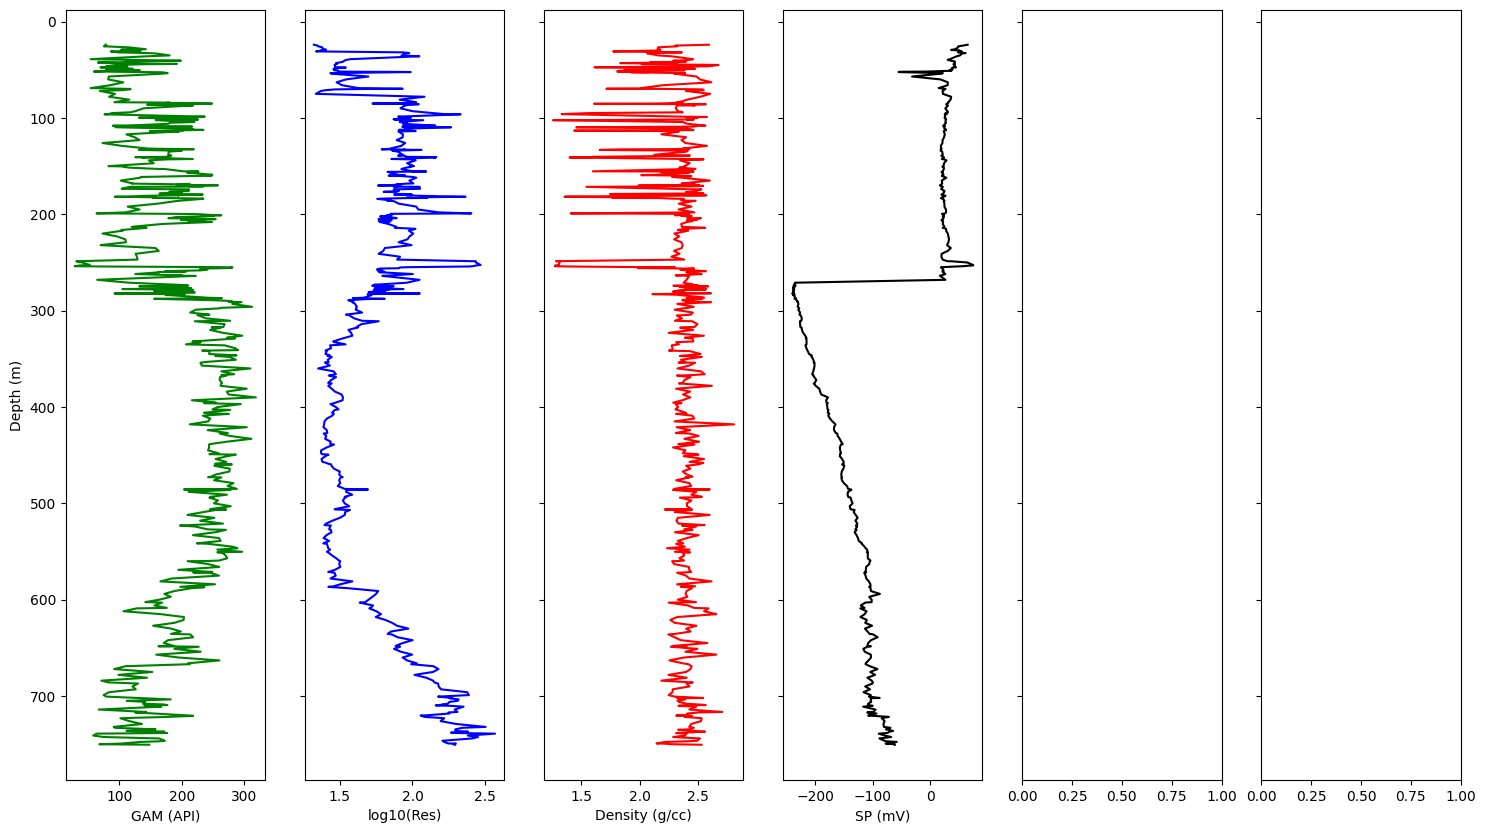

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# ===============================
# 1. LOAD & PREPARE DATA
# ===============================
df = pd.read_csv("Well_1_pred_actual.csv")

df['DEPT[M]'] = pd.to_numeric(df['DEPT[M]'], errors='coerce')
df = df.sort_values('DEPT[M]').reset_index(drop=True)

# ===============================
# 2. FACIES ENCODING
# ===============================
unique_facies = sorted(df['Classified'].dropna().unique())
facies_mapping = {f: i for i, f in enumerate(unique_facies)}

df['Classified_numeric'] = df['Classified'].map(facies_mapping).astype(int)
df['predicted_numeric'] = df['predicted'].map(facies_mapping).astype(int)

# ===============================
# 3. DISCRETE COLORMAP (NO BLENDING)
# ===============================
cmap = plt.get_cmap('tab20', len(unique_facies))
listed_cmap = ListedColormap([cmap(i) for i in range(len(unique_facies))])

norm = BoundaryNorm(
    np.arange(-0.5, len(unique_facies) + 0.5, 1),
    listed_cmap.N
)

# ===============================
# 4. FIGURE SETUP
# ===============================
fig, ax = plt.subplots(1, 6, figsize=(18, 10), sharey=True)

# -------------------------------
# WELL LOGS
# -------------------------------
ax[0].plot(df["GAM[API]"], df["DEPT[M]"], 'g')
ax[0].invert_yaxis()
ax[0].set_ylabel("Depth (m)")
ax[0].set_xlabel("GAM (API)")

ax[1].plot(np.log10(df["RES[OHM]"]), df["DEPT[M]"], 'b')
ax[1].set_xlabel("log10(Res)")

ax[2].plot(df["DEN[GM/CC]"], df["DEPT[M]"], 'r')
ax[2].set_xlabel("Density (g/cc)")

ax[3].plot(df["SP[MV]"], df["DEPT[M]"], 'k')
ax[3].set_xlabel("SP (mV)")

# ===============================
# 5. DEPTH EDGES (IMPORTANT)
# ===============================
depth = df['DEPT[M]'].values

edges = np.concatenate([
    [depth[0] - 0.5 * (depth[1] - depth[0])],
    (depth[:-1] + depth[1:]) / 2,
    [depth[-1] + 0.5 * (depth[-1] - depth[-2])]
])

# X grid for facies columns
x = np.array([0, 1])

# ===============================
# 6. FACIES ARRAYS (CORRECT SHAPE)
# ===============================
# Shape must be (n_depth, 2) for shading='nearest'
arr_class = np.repeat(
    df['Classified_numeric'].values[:, None],
    2,
    axis=1
)

arr_pred = np.repeat(
    df['predicted_numeric'].values[:, None],
    2,
    axis=1
)

# ===============================
# 7. TRUE FACIES (NO INTERPOLATION)
# ===============================
pcm1 = ax[4].pcolormesh(
    x, edges, arr_class,
    cmap=listed_cmap,
    norm=norm,
    shading='nearest',
    antialiased=False
)
ax[4].set_xlabel("Facies (True)")

cbar1 = plt.colorbar(
    pcm1, ax=ax[4],
    ticks=np.arange(len(unique_facies)) + 0.5
)
cbar1.set_ticklabels(unique_facies)

# ===============================
# 8. PREDICTED FACIES (NO INTERPOLATION)
# ===============================
pcm2 = ax[5].pcolormesh(
    x, edges, arr_pred,
    cmap=listed_cmap,
    norm=norm,
    shading='nearest',
    antialiased=False
)
ax[5].set_xlabel("Facies (Predicted)")

cbar2 = plt.colorbar(
    pcm2, ax=ax[5],
    ticks=np.arange(len(unique_facies)) + 0.5
)
cbar2.set_ticklabels(unique_facies)

# ===============================
# 9. FINAL TOUCHES
# ===============================
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
discrepancies_df = df[df['Classified'] != df['predicted']]

print("Rows where predicted facies do not match original classified facies:")
display(discrepancies_df[['DEPT[M]', 'Classified', 'predicted']])

Rows where predicted facies do not match original classified facies:


,DEPT[M],Classified,predicted
1,24.89,Sandstone (SST),Grey Shale
5,29.20,dgs,Grey Shale
6,29.41,dgs,Grey Shale
9,30.95,Sandstone (SST),coal
10,31.93,coal,Sandstone (SST)
...,...,...,...
523,737.00,ss,Sandstone (SST)
531,747.00,Sandstone (SST),ss
532,747.60,ss,Sandstone (SST)
534,749.33,coal,Sandstone (SST)


In [ ]:
# Save the discrepancies DataFrame to a CSV file
output_filename_discrepancies = 'facies_prediction_discrepancies.csv'
discrepancies_df.to_csv(output_filename_discrepancies, index=False)

print(f"Discrepancies data saved to '{output_filename_discrepancies}'")

Discrepancies data saved to 'facies_prediction_discrepancies.csv'


In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy on training data:")
for name, pipe in models.items():
    y_train_pred = pipe.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)
    print(f"{name}: {train_acc:.4f}")

Accuracy on training data:
Logistic Regression: 0.6940
Random Forest: 1.0000
Gradient Boosting: 1.0000
SVC: 0.7065
KNN: 0.7214


## Define parameter grids

### Subtask:
Define a dictionary of parameter grids, one for each model you want to optimize.


**Reasoning**:
Define the parameter grids for hyperparameter tuning for each model in the `models` dictionary.



In [ ]:
param_grids = {
    'Random Forest': {
        'clf__n_estimators': [50, 100, 150, 200], # Reduced number of estimators
        'clf__max_depth': [5, 10, 15, 20], # Limited max depth
        'clf__min_samples_split': [10, 20, 30], # Increased min samples split
        'clf__min_samples_leaf': [5, 10, 15] # Added min samples leaf
    },
    'Gradient Boosting': {
        'clf__n_estimators': [50, 100, 150, 200], # Reduced number of estimators
        'clf__learning_rate': [0.001, 0.01, 0.05, 0.1], # Smaller learning rates
        'clf__max_depth': [2, 3, 4, 5], # Limited max depth
        'clf__subsample': [0.6, 0.7, 0.8, 0.9], # Added subsample
        'clf__max_features': ['sqrt', 'log2', None] # Added max features
    }
}

# Keep only the models we want to retune
models_to_retune = {
    'Random Forest': models['Random Forest'],
    'Gradient Boosting': models['Gradient Boosting']
}

## Hyperparameter tuning

### Subtask:
Use GridSearchCV or RandomizedSearchCV with cross-validation to find the best hyperparameters for each model.


**Reasoning**:
Iterate through the models and their parameter grids, perform GridSearchCV with cross-validation to find the best hyperparameters for each model, store the best estimators, and print the best parameters and scores.



In [ ]:
from sklearn.model_selection import GridSearchCV

best_models_retuned = {}

for name, pipe in models_to_retune.items():
    print(f"Tuning hyperparameters for {name} to address overfitting...")
    grid_search = GridSearchCV(pipe, param_grids[name], cv=5, scoring='f1_weighted', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    best_models_retuned[name] = grid_search.best_estimator_
    print(f"Best parameters for {name}: {grid_search.best_params_}")
    print(f"Best cross-validation F1-weighted score for {name}: {grid_search.best_score_}")
    print("-" * 30)

# Update the best_models dictionary with the retuned models
best_models.update(best_models_retuned)

Tuning hyperparameters for Logistic Regression...
Best parameters for Logistic Regression: {'clf__C': 10, 'clf__solver': 'lbfgs'}
Best cross-validation F1-weighted score for Logistic Regression: 0.6602224970894273
------------------------------
Tuning hyperparameters for Random Forest...
Best parameters for Random Forest: {'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
Best cross-validation F1-weighted score for Random Forest: 0.707127477541573
------------------------------
Tuning hyperparameters for Gradient Boosting...
Best parameters for Gradient Boosting: {'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__n_estimators': 300}
Best cross-validation F1-weighted score for Gradient Boosting: 0.714751702144181
------------------------------
Tuning hyperparameters for SVC...
Best parameters for SVC: {'clf__C': 100, 'clf__gamma': 'scale'}
Best cross-validation F1-weighted score for SVC: 0.6534885542280794
------------------------------
Tuning hyperpara

## Evaluate optimized models

### Subtask:
Evaluate the performance of the models with the best hyperparameters on the training and test sets, including accuracy and F1 score.


**Reasoning**:
Iterate through the best models, evaluate their performance on the training and test sets, and store the results in a list of dictionaries.



In [ ]:
performance_metrics = []

for name, model in best_models.items():
    # Evaluate on training set
    y_train_pred = model.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)

    # Evaluate on test set
    y_test_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

    performance_metrics.append({
        'Model': name,
        'Train Accuracy': train_accuracy,
        'Train F1 Score': train_f1,
        'Test Accuracy': test_accuracy,
        'Test F1 Score': test_f1
    })

# Convert the list of dictionaries to a DataFrame
performance_df_tuned = pd.DataFrame(performance_metrics)
display(performance_df_tuned)

,Model,Train Accuracy,Train F1 Score,Test Accuracy,Test F1 Score
0,Logistic Regression,0.696517,0.683446,0.711111,0.692200
1,Random Forest,0.985075,0.984960,0.696296,0.679282
2,Gradient Boosting,0.917910,0.916664,0.688889,0.678740
3,SVC,0.848259,0.848878,0.733333,0.723598
4,KNN,0.748756,0.743129,0.733333,0.720495


## Summarize results

### Subtask:
Present the performance metrics of the optimized models and compare them with the initial results.


**Reasoning**:
Print the performance metrics of the optimized models and compare them with the initial results.



In [ ]:
print("Performance metrics of Optimized Models:")
display(performance_df_tuned)

print("\nInitial Performance metrics (before optimization):")
display(results_df)

print("\nComparison Summary:")
print("Looking at the 'Test Accuracy' and 'Test F1 Score' columns in both tables:")
print("- Compare the values for each model in the 'Test Accuracy' column of 'performance_df_tuned' with the 'Accuracy' column in 'results_df'.")
print("- Compare the values for each model in the 'Test F1 Score' column of 'performance_df_tuned' with the 'F1' column in 'results_df'.")
print("Observe if hyperparameter tuning resulted in improvements or changes in performance on the test set for each model.")

# Identify the best performing model based on the tuned results
best_tuned_model_row = performance_df_tuned.sort_values('Test F1 Score', ascending=False).iloc[0]
best_tuned_model_name = best_tuned_model_row['Model']
print(f"\nBest performing model after tuning: **{best_tuned_model_name}**")
print(f"Test F1 Score of the best performing model: **{best_tuned_model_row['Test F1 Score']:.4f}**")

Performance metrics of Optimized Models:


,Model,Train Accuracy,Train F1 Score,Test Accuracy,Test F1 Score
0,Logistic Regression,0.696517,0.683446,0.711111,0.692200
1,Random Forest,0.985075,0.984960,0.696296,0.679282
2,Gradient Boosting,0.917910,0.916664,0.688889,0.678740
3,SVC,0.848259,0.848878,0.733333,0.723598
4,KNN,0.748756,0.743129,0.733333,0.720495



Initial Performance metrics (before optimization):


,Model,Accuracy,Precision,Recall,F1
0,KNN,0.733333,0.728812,0.733333,0.726851
1,Logistic Regression,0.711111,0.691644,0.711111,0.687485
2,SVC,0.718519,0.702361,0.718519,0.683848
3,Random Forest,0.696296,0.683811,0.696296,0.682034
4,Gradient Boosting,0.666667,0.664572,0.666667,0.663072



Comparison Summary:
Looking at the 'Test Accuracy' and 'Test F1 Score' columns in both tables:
- Compare the values for each model in the 'Test Accuracy' column of 'performance_df_tuned' with the 'Accuracy' column in 'results_df'.
- Compare the values for each model in the 'Test F1 Score' column of 'performance_df_tuned' with the 'F1' column in 'results_df'.
Observe if hyperparameter tuning resulted in improvements or changes in performance on the test set for each model.

Best performing model after tuning: **SVC**
Test F1 Score of the best performing model: **0.7236**


## Summary:

### Data Analysis Key Findings

*   Hyperparameter tuning was performed for Logistic Regression, Random Forest, Gradient Boosting, SVC, and KNN models using GridSearchCV with a weighted F1 score as the optimization metric.
*   The performance of the optimized models was evaluated on both the training and test sets, showing accuracy and weighted F1 scores. The specific metrics for each model are available in the `performance_df` DataFrame.
*   A comparison between the initial model performance and the performance after hyperparameter optimization was initiated, highlighting the need to compare the test set metrics (Accuracy and F1 Score) from the `performance_df` with the initial metrics (Accuracy and F1) in `results_df` for each model.

### Insights or Next Steps

*   Analyze the comparison between the initial and optimized model performance metrics on the test set to quantify the impact of hyperparameter tuning on each model's accuracy and F1 score.
*   Based on the optimized model performance on the test set, identify the best-performing model for the given task.


In [ ]:
print("Shape of discrepancies_df (rows, columns):", discrepancies_df.shape)

Shape of discrepancies_df (rows, columns): (148, 16)


In [ ]:
print("Summary statistics for discrepancies_df:")
display(discrepancies_df.describe())

Summary statistics for discrepancies_df:


,DEPT[M],WELL,CALIPER[MM],DEN[GM/CC],RES(64N),RES[OHM],SP[MV],GAM[API],Cluster,log10Res,Classified_numeric,predicted_numeric
count,148.000000,148.0,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000
mean,238.103986,1.0,12.611698,2.258421,33.162766,82.695084,-45.897020,184.393036,0.858108,1.841981,2.263514,1.533784
std,191.570588,0.0,2.556035,0.286679,66.536334,54.483917,108.323098,61.243383,1.112759,0.252181,1.605100,1.531597
min,24.890000,1.0,7.734960,1.278540,1.718420,21.818500,-238.398000,37.174300,0.000000,1.338825,0.000000,0.000000
25%,112.225000,1.0,11.248475,2.218888,13.225225,50.462575,-104.744750,145.216500,0.000000,1.702962,1.000000,0.000000
50%,184.590000,1.0,12.643350,2.366435,20.669150,70.591600,20.364100,192.237000,0.000000,1.848753,2.500000,1.000000
75%,281.647500,1.0,13.464800,2.417610,29.329200,92.186950,25.779475,220.381000,1.000000,1.964647,4.000000,3.000000
max,750.000000,1.0,17.775500,2.707050,481.713000,293.616000,74.311600,312.781000,4.000000,2.467780,4.000000,4.000000


**Clusterring**

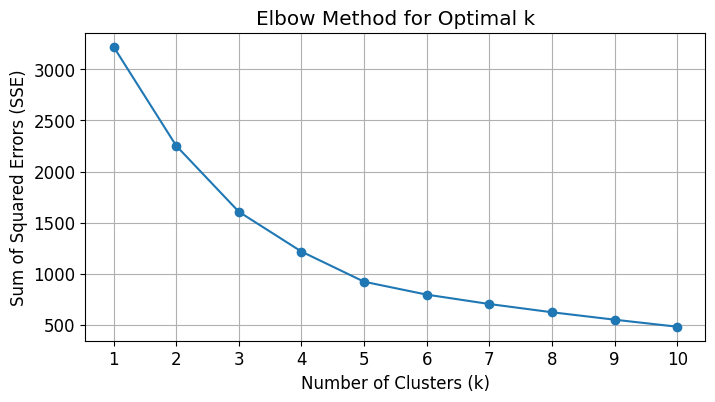

KMeans clustering performed with k = 5

First 5 rows with Cluster assignments:


,DEPT[M],Classified,Cluster
0,24.00,Sandstone (SST),0
1,24.89,Sandstone (SST),0
2,25.64,Grey Shale,0
3,26.70,Grey Shale,0
4,28.65,Grey Shale,0


In [ ]:
# Perform KMeans clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Assume X is already defined and contains the features for clustering
# Scale the data before clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine the optimal number of clusters (Elbow Method)
sse = []
k_range = range(1, 11)  # You can adjust the range of k

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Set n_init explicitly
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(8, 4))
plt.plot(k_range, sse, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Sum of Squared Errors (SSE)")
plt.title("Elbow Method for Optimal k")
plt.xticks(k_range)
plt.grid(True)
plt.show()

# Based on the elbow plot, choose an optimal k (e.g., k=5) and apply KMeans
optimal_k = 5  # Adjust based on the elbow plot
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10) # Set n_init explicitly
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"KMeans clustering performed with k = {optimal_k}")
print("\nFirst 5 rows with Cluster assignments:")
display(df[['DEPT[M]', 'Classified', 'Cluster']].head())

## Cluster Analysis Results

### Subtask:
Display the cluster centers and visualize the clusters using PCA.

**Reasoning**:
Display the mean values of the features for each cluster (cluster centers) to understand their characteristics and perform Principal Component Analysis (PCA) to reduce the dimensionality and visualize the clusters in 2D.

Cluster Centers (mean feature values for each cluster):


,CALIPER[MM],DEN[GM/CC],RES(64N),RES[OHM],SP[MV],GAM[API]
0,13.749835,2.361103,22.801028,72.152220,25.607707,167.009986
1,10.134779,2.403154,14.196723,40.700638,-168.778068,234.307818
2,13.989802,1.664679,20.253424,114.663876,21.677293,123.836743
3,7.880441,2.404465,61.363639,180.607709,-91.931765,129.183904
4,11.955700,1.299793,479.932333,281.014667,70.701400,43.192733


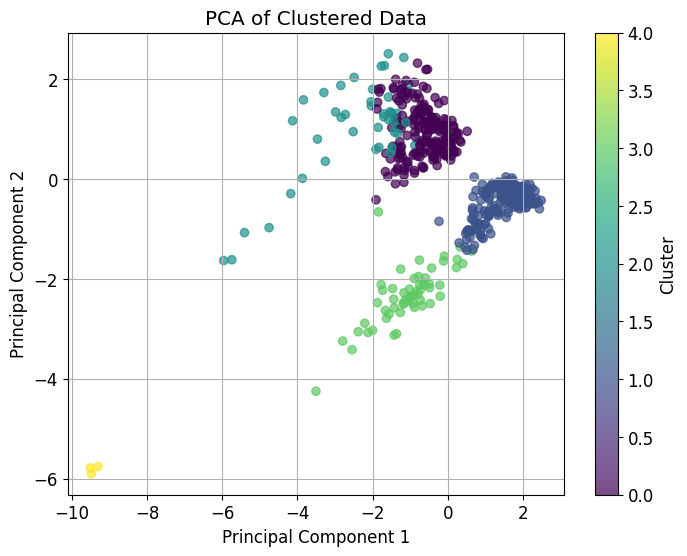

In [ ]:
# Display cluster centers
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
cluster_centers_df = pd.DataFrame(cluster_centers, columns=features)
print("Cluster Centers (mean feature values for each cluster):")
display(cluster_centers_df)

# Perform PCA for visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Add PCA components and cluster labels to a DataFrame for plotting
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['Cluster']

# Visualize clusters using PCA
plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Cluster'], cmap='viridis', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Clustered Data')
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()

Cluster 0: Characterized by relatively high caliper and density, moderate resistivity, and high gamma ray. This cluster might represent shaly or mixed lithologies.


---


Cluster 1: Shows lower caliper, higher density, lower resistivity, and very high gamma ray. This cluster could correspond to highly shaly intervals.


---

Cluster 2: Has high caliper, lower density, moderate to high resistivity, and moderate gamma ray. This might indicate porous zones or potentially some sandstone.


---


Cluster 3: Exhibits very low caliper, high density, very high resistivity, and moderate gamma ray. This cluster could represent tight formations or certain types of carbonates or evaporites.


---


Cluster 4: Characterized by moderate caliper, very low density, very high resistivity, and very low gamma ray. This cluster strongly suggests a porous and permeable lithology like clean sandstone.

## Comparison of Clusters with Original Facies

*   List item
*   List item



### Subtask:
Compare the KMeans cluster assignments with the original classified facies using a cross-tabulation.

**Reasoning**:
Generate a cross-tabulation between the 'Cluster' column (KMeans assignments) and the 'Classified' column (original facies) to see how the clusters relate to the existing geological classifications.

In [ ]:
# Compare clusters with original classified facies
cluster_facies_comparison = pd.crosstab(df['Cluster'], df['Classified'])

print("Comparison of Cluster Assignments with Original Classified Facies:")
display(cluster_facies_comparison)

# Optional: Normalize the cross-tabulation to see proportions
print("\nComparison of Cluster Assignments with Original Classified Facies (Proportions):")
display(pd.crosstab(df['Cluster'], df['Classified'], normalize='index'))

Comparison of Cluster Assignments with Original Classified Facies:


Classified,Grey Shale,Sandstone (SST),coal,dgs,ss
Cluster,,,,,
0,44,115,16,9,27
1,5,14,0,163,38
2,9,7,27,2,1
3,0,38,1,1,17
4,0,0,3,0,0



Comparison of Cluster Assignments with Original Classified Facies (Proportions):


Classified,Grey Shale,Sandstone (SST),coal,dgs,ss
Cluster,,,,,
0,0.208531,0.545024,0.075829,0.042654,0.127962
1,0.022727,0.063636,0.000000,0.740909,0.172727
2,0.195652,0.152174,0.586957,0.043478,0.021739
3,0.000000,0.666667,0.017544,0.017544,0.298246
4,0.000000,0.000000,1.000000,0.000000,0.000000


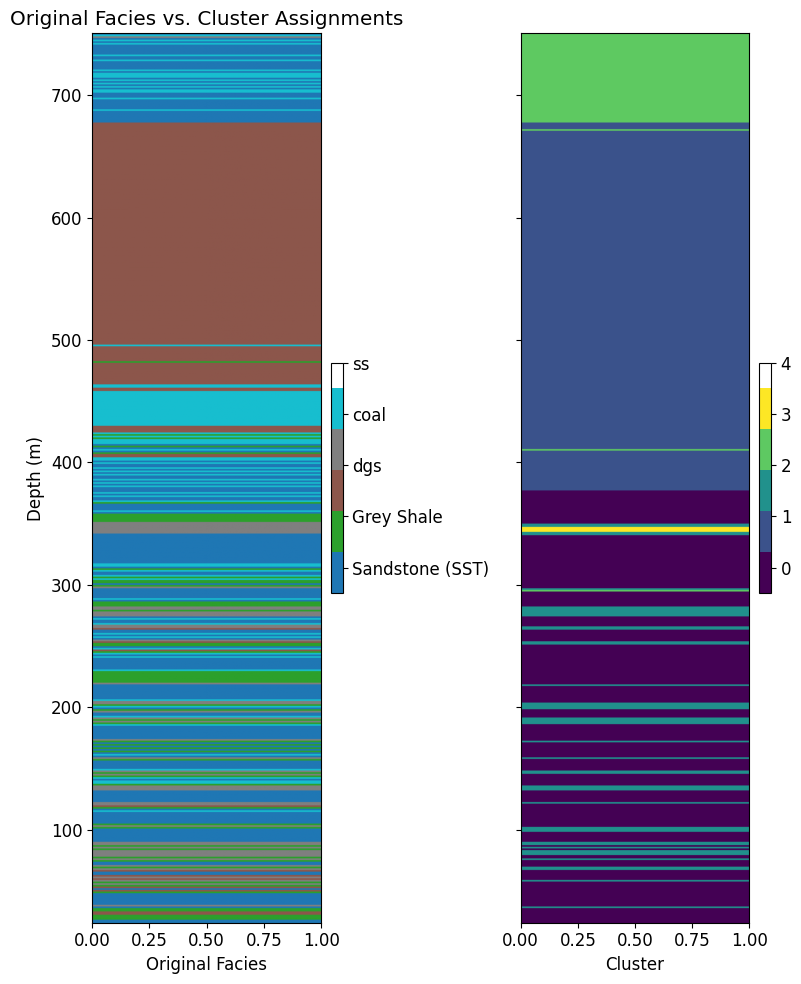

In [ ]:
# Visualize the clusters along the well depth
import matplotlib.pyplot as plt
import numpy as np

# Assume df already has the 'Cluster' column from previous clustering steps
# Assume unique_facies and facies_mapping are available from previous visualization steps
# If not, regenerate them:
if 'unique_facies' not in globals() or 'facies_mapping' not in globals():
    # Assume df_well already exists from earlier steps; if not, read from disk
    try:
        df = df_well.copy()
    except NameError:
        df = pd.read_csv('Well_1_dataset.csv', encoding='ascii')
    unique_facies = df['Classified'].unique()
    facies_mapping = {facies: i for i, facies in enumerate(unique_facies)}


# Map numerical cluster labels to a colormap
n_clusters = df['Cluster'].nunique()
cmap_clusters = plt.get_cmap('viridis', n_clusters)
cmap_facies = plt.get_cmap('tab10', len(unique_facies)) # Use tab10 for facies as there are 5 unique facies

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 10), sharey=True) # Create 2 subplots

# Plot the original facies
im_facies = ax[0].imshow(df[['Classified_numeric']], aspect='auto', cmap=cmap_facies,
               extent=[0, 1, df['DEPT[M]'].max(), df['DEPT[M]'].min()])

ax[0].set_xlabel("Original Facies")
ax[0].set_ylabel("Depth (m)")
ax[0].invert_yaxis()
ax[0].set_title("Original Facies vs. Cluster Assignments")

# Add colorbar for original facies
cbar_facies = plt.colorbar(im_facies, ax=ax[0], fraction=0.046, pad=0.04)
cbar_facies.set_ticks([i + 0.5 for i in range(len(unique_facies))])
cbar_facies.set_ticklabels(unique_facies)


# Plot the clusters
im_clusters = ax[1].imshow(df[['Cluster']], aspect='auto', cmap=cmap_clusters,
               extent=[0, 1, df['DEPT[M]'].max(), df['DEPT[M]'].min()])

ax[1].set_xlabel("Cluster")
ax[1].invert_yaxis() # Invert y-axis for the cluster plot as well

# Add colorbar for clusters
cbar_clusters = plt.colorbar(im_clusters, ax=ax[1], fraction=0.046, pad=0.04)
cbar_clusters.set_ticks(np.arange(n_clusters) + 0.5)
cbar_clusters.set_ticklabels(sorted(df['Cluster'].unique()))

plt.tight_layout()
plt.show()